In [48]:
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_raw_dataset
from utils.face_recognition import load_insightface_model, get_embeddings, allign_faces, FaceDetector
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
import torch 
from tqdm import tqdm

In [3]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
DATASET_DIR = DATA_DIR / "test_geneset_embeddings"

GENESET = "easy"

In [79]:
celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
easy_geneset = ProcessedDataset(DATA_DIR / "easy_geneset_embeddings")


100%|██████████| 5/5 [00:00<00:00, 280.11it/s]

  0%|          | 0/491 [07:20<?, ?it/s]


# IP-adapter

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/insightface/utils/transform.py:68: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  P = np.linalg.lstsq(X_homo, Y)[0].T # Affine matrix. 3 x 4


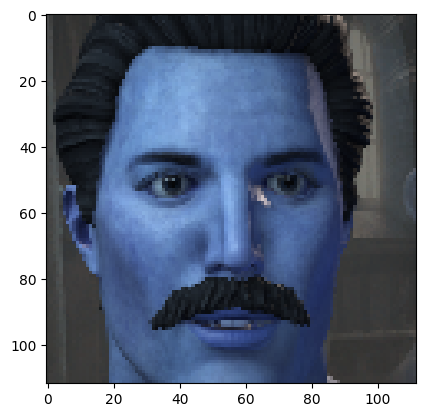

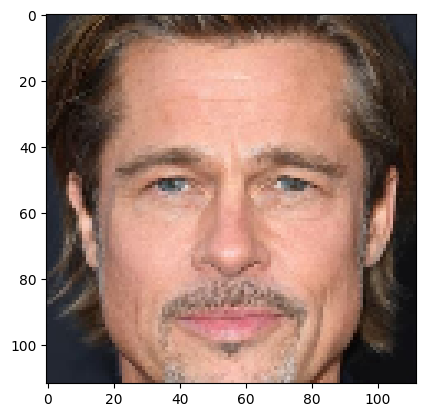

In [125]:
import cv2
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)
print(app.models.items())

ck_image = cv2.imread("../../data/ck_faces_dataset/freddie_mercury/freddie_mercury.png")
real_image = cv2.imread("../../data/real_faces_dataset/brad_pit/006_aee8d88b.jpg")

def get_embed(app, image):
    faces = app.get(image)
    faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
    landmarks = faces[0].kps
    aligned = face_align.norm_crop(image, landmark=landmarks, image_size=112)
    return faceid_embeds, aligned

def get_embed_from_alligned(app, image):
    model = app.models["recognition"]
    emb = model.get_feat(image).flatten()
    return torch.tensor(emb), image

# ck_aligned = allign_faces(np.array(ck_image)[None, :], FaceDetector(), [""], None)[0][0]
# print(ck_aligned.shape)
ck_embed, ck_aligned = get_embed(app, ck_image)#get_embed_from_alligned(app, easy_geneset.alligned_images[np.random.randint(0, len(easy_geneset.alligned_images))])
real_embed, real_aligned = get_embed(app, real_image)

plt.imshow(ck_aligned)
plt.show()
plt.imshow(cv2.cvtColor(real_aligned, cv2.COLOR_BGR2RGB))
plt.show()


In [108]:
ck_embed.shape

torch.Size([512])

In [84]:
# cosine similarity 
cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cos(ck_embed, real_embed)

tensor([-0.0752])

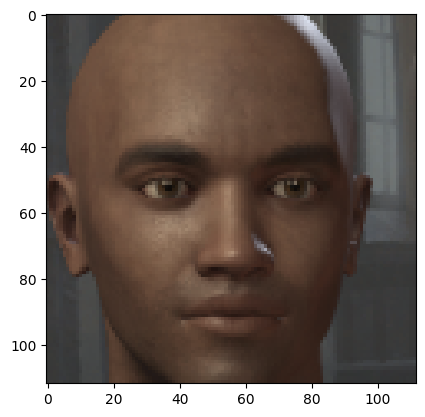

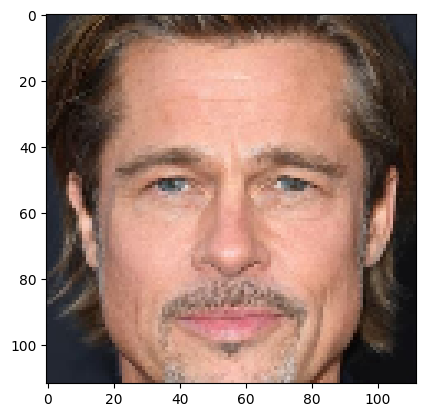

## generate image

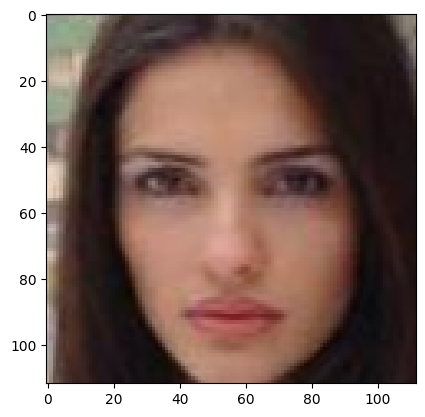

In [77]:
plt.imshow(celeba_dataset.alligned_images[0])

In [128]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image
from huggingface_hub import hf_hub_download

from thirdparty.ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus

v2 = False
base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
image_encoder_path = "laion/CLIP-ViT-H-14-laion2B-s32B-b79K"
repo_id = "h94/IP-Adapter-FaceID"
ip_ckpt = "ip-adapter-faceid-plus_sd15.bin" if not v2 else "ip-adapter-faceid-plusv2_sd15.bin"
device = "cpu"
ckpt_path = hf_hub_download(repo_id=repo_id, filename=ip_ckpt)

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float32)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float32,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)

# load ip-adapter
ip_model = IPAdapterFaceIDPlus(pipe, image_encoder_path, ckpt_path, device, torch_dtype=torch.float32)

# generate image
prompt = "frontal portrait of a game character"
negative_prompt = "side view"

images = ip_model.generate(
     prompt=prompt, negative_prompt=negative_prompt, face_image=real_aligned, faceid_embeds=ck_embed, shortcut=v2, s_scale=5.0,
     num_samples=4, width=256, height=256, num_inference_steps=30, seed=2023
)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...: 100%|██████████| 5/5 [00:09<00:00,  1.82s/it]
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/diffusers/models/lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer"

In [129]:
images

[<PIL.Image.Image image mode=RGB size=256x256>,
 <PIL.Image.Image image mode=RGB size=256x256>,
 <PIL.Image.Image image mode=RGB size=256x256>,
 <PIL.Image.Image image mode=RGB size=256x256>]

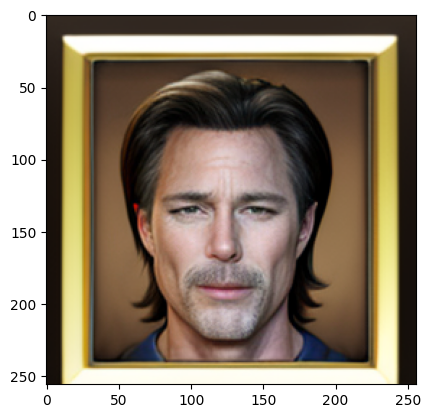

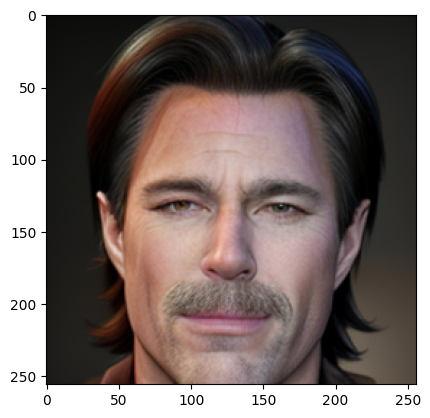

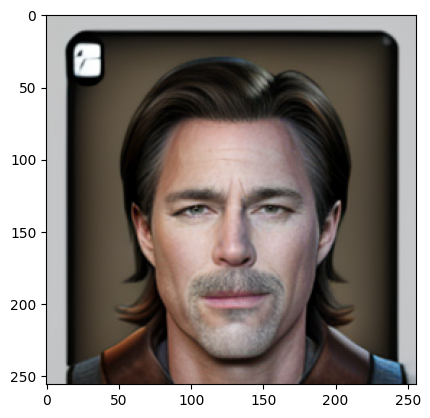

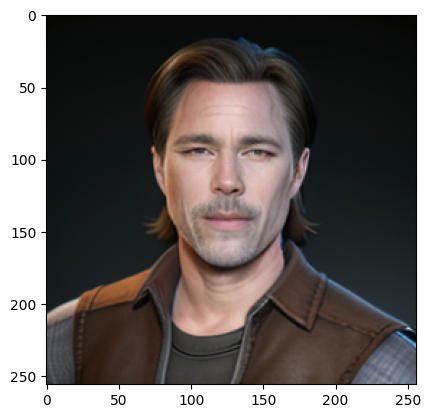

: 

In [130]:
for image in images:
    plt.imshow(image)
    plt.show()
# plt.imshow(images[0])

In [50]:
for i, im in enumerate(images):
    # save 
    im.save(f"generated_v2{i}.png")

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/1k3d68.onnx landmark_3d_68
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/2d106det.onnx landmark_2d_106
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/genderage.onnx genderage
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /Users/czyjtu/.insightface/models/antelopev2/glintr100.onnx recognition
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/czyjtu/.insightface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (640, 640)


100%|██████████| 1/1 [00:00<00:00, 14.13it/s]


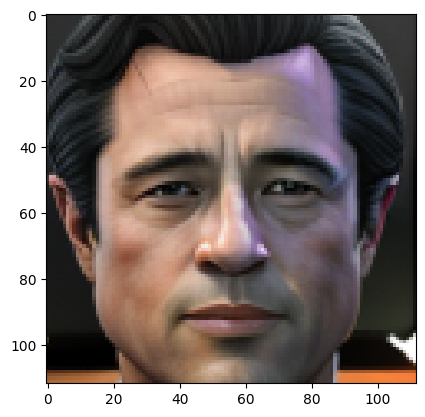

(4, 13)
-0.051189613 0.6597408


100%|██████████| 6/6 [00:00<00:00, 192.93it/s]


In [54]:
import torch
from torch import nn
import pytorch_lightning as pl
from torch.nn import functional as F
from sklearn.preprocessing import normalize


class DNARegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressor, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    

class MLP(pl.LightningModule):
    def __init__(self, model: nn.Module):
        super(MLP, self).__init__()
        self.model = model 
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss
import torch as th 

mlp = MLP.load_from_checkpoint("../../experiments/easy_geneset_embeddings/mlp_model.ckpt")
mlp.eval()
mlp.to("cpu")

arcface_model = load_insightface_model("../../thirdparty/recognition/weights/arcface_r100.pth")
allinged_images, _ = allign_faces(np.array(images), FaceDetector(), [""] * len(images), None)
embed_generated = normalize(get_embeddings(allinged_images, arcface_model))

plt.imshow(allinged_images[0])
plt.show()
pred = mlp.forward(th.tensor(embed_generated).float()).detach().numpy()
print(pred.shape)
print(pred.min(), pred.max())

X_train_sc, X_val_sc, X_test_sc, Y_train, Y_val, Y_test, train_images, val_images, test_images, scaler_x = load_geneset_dataset(GENESET)
save_predicitons(pred, scaler_x, Path("./dna_brad_pit_augmented"), GENESET) 